# Building autograd from nothing

Notes from rebuilding scalar reverse-mode automatic differentiation, in the order the ideas arrive: a numerical derivative as ground truth, a `Value` class that records how each number was produced, the chain rule applied backward through that record, the classic gradient-accumulation bug, and at the end a three-neuron network training by gradient descent.

The repo already contains the finished versions. `micrograd.py` is the scalar engine this notebook builds toward; `engine.py` is the same construction on NumPy arrays. The last two code cells import both.

In [1]:
# The derivative, measured by nudging.
# f(x) = 3x^2 - 4x, so f'(x) = 6x - 4 and f'(3) = 14 exactly.
# The symmetric difference (f(x+h) - f(x-h)) / 2h has error O(h^2),
# one order better than the one-sided version.

def f(x):
    return 3 * x**2 - 4 * x

x, h = 3.0, 1e-6
estimate = (f(x + h) - f(x - h)) / (2 * h)
exact = 6 * x - 4

print(f"nudge estimate: {estimate:.9f}")
print(f"exact:          {exact:.9f}")
assert abs(estimate - exact) < 1e-6

nudge estimate: 14.000000002
exact:          14.000000000


A derivative is a sensitivity: nudge an input by $h$, watch how far the output moves, divide. That definition works on any function I can call, which makes nudging the ground truth for this notebook. Every gradient an engine produces below gets checked against a finite difference at least once.

Nudging is also why an engine is needed at all. It costs one extra evaluation of $f$ per input, and a network's loss is one function of millions of inputs, the parameters. Training needs every $\partial L / \partial w_i$ from a constant number of passes, which is what reverse mode provides.

In [2]:
# A Value wraps one float and records how it was produced: _prev holds the
# input Values, _op names the operation. grad will eventually hold the
# derivative of the final output with respect to this value; nothing fills
# it yet. Only the two ops needed for a*b + c exist so far.

class Value:
    def __init__(self, data, _children=(), _op=""):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op

    def __add__(self, other):
        return Value(self.data + other.data, (self, other), "+")

    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), "*")

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

a = Value(2.0)
b = Value(-3.0)
d = a * b + Value(10.0)
print(d, "  op:", d._op, "  inputs:", sorted(c.data for c in d._prev))

Value(data=4.0, grad=0.0)   op: +   inputs: [-6.0, 10.0]


In [3]:
# The expression d = a*b + c as a graph (values in parens):
#
#   a (2) ---\
#             [*] --- e (-6) ---\
#   b (-3) --/                   [+] --- d (4)
#   c (10) ---------------------/
#
# Backward pass by hand, output first. d.grad is dd/dd = 1.
# Through +: d = e + c, so dd/de = 1 and dd/dc = 1; the gradient passes through.
# Through *: e = a * b, so de/da = b and de/db = a. The chain rule multiplies
# each local derivative by the gradient arriving from above.

a, b, c = Value(2.0), Value(-3.0), Value(10.0)
e = a * b
d = e + c

d.grad = 1.0
e.grad = 1.0 * d.grad      # dd/de = 1
c.grad = 1.0 * d.grad      # dd/dc = 1
a.grad = b.data * e.grad   # de/da = b
b.grad = a.data * e.grad   # de/db = a

# Check every one of those by nudging the same expression in plain floats.
def f_num(av, bv, cv):
    return av * bv + cv

h = 1e-6
checks = [
    ("a", a.grad, (f_num(2 + h, -3, 10) - f_num(2 - h, -3, 10)) / (2 * h)),
    ("b", b.grad, (f_num(2, -3 + h, 10) - f_num(2, -3 - h, 10)) / (2 * h)),
    ("c", c.grad, (f_num(2, -3, 10 + h) - f_num(2, -3, 10 - h)) / (2 * h)),
]
for name, manual, nudge in checks:
    print(f"dd/d{name}: by hand {manual:+.6f}   nudge {nudge:+.6f}")
    assert abs(manual - nudge) < 1e-6

dd/da: by hand -3.000000   nudge -3.000000
dd/db: by hand +2.000000   nudge +2.000000
dd/dc: by hand +1.000000   nudge +1.000000


Each step of that hand pass used only the local derivative of a single operation: addition passes the incoming gradient through unchanged, multiplication scales it by the other operand. The chain rule does the composing, multiplying the local derivative by the gradient that arrives from the output side. No node needs to know anything about the rest of the graph.

So every operation can carry a small closure holding just its own rule, and a backward pass is a matter of calling those closures in the right order.

In [4]:
# Same class, but each op now also builds a _backward closure that pushes
# the output's gradient to the inputs through its local derivative.
# I write the input grads with plain "=" for now; a later cell shows the
# case where that is wrong.

class Value:
    def __init__(self, data, _children=(), _op=""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None   # leaves have nothing to push back
        self._prev = set(_children)
        self._op = _op

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), "+")
        def _backward():
            self.grad = out.grad              # d(a+b)/da = 1
            other.grad = out.grad             # d(a+b)/db = 1
        out._backward = _backward
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), "*")
        def _backward():
            self.grad = other.data * out.grad   # d(a*b)/da = b
            other.grad = self.data * out.grad   # d(a*b)/db = a
        out._backward = _backward
        return out

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

a, b, c = Value(2.0), Value(-3.0), Value(10.0)
e = a * b
d = e + c

d.grad = 1.0    # seed the output: dd/dd = 1
d._backward()   # fills e.grad and c.grad
e._backward()   # fills a.grad and b.grad

print(f"a.grad={a.grad}  b.grad={b.grad}  c.grad={c.grad}")
assert (a.grad, b.grad, c.grad) == (-3.0, 2.0, 1.0)   # same as the hand pass

a.grad=-3.0  b.grad=2.0  c.grad=1.0


In [5]:
# Calling the closures by hand only works if I order them myself: a node's
# _backward must run after its own grad is final. A depth-first topological
# sort gives that order; walked in reverse, it is the backward schedule.
# Recursion is fine at this scale. engine.py builds the same order with an
# explicit stack, because a deep graph (a transformer forward pass has
# thousands of nodes) would hit Python's recursion limit.

def backward(self):
    topo, visited = [], set()
    def build(v):
        if v not in visited:
            visited.add(v)
            for child in v._prev:
                build(child)
            topo.append(v)
    build(self)
    self.grad = 1.0
    for v in reversed(topo):
        v._backward()

Value.backward = backward

a, b, c = Value(2.0), Value(-3.0), Value(10.0)
d = a * b + c
d.backward()
print(f"a.grad={a.grad}  b.grad={b.grad}  c.grad={c.grad}")
assert (a.grad, b.grad, c.grad) == (-3.0, 2.0, 1.0)

a.grad=-3.0  b.grad=2.0  c.grad=1.0


The class above has a bug. When one node feeds two consumers, both push gradient into it during the backward pass, and plain assignment keeps only the last write. The multivariate chain rule says contributions from different paths must add: in $b = a + a$, the input $a$ is used twice, so $db/da = 2$.

The next cell shows the failure, the one after it the fix: accumulate with `+=` into grads that start at zero. That accumulation is also why frameworks make you zero gradients between training steps; `+=` keeps adding across backward passes unless something resets it.

In [6]:
# One node used twice. In __add__'s closure, self and other are the same
# object here, so the second assignment overwrites the first.

a = Value(3.0)
b = a + a
b.backward()

h = 1e-6
nudge = (((3 + h) + (3 + h)) - ((3 - h) + (3 - h))) / (2 * h)
print(f"a.grad with '=' : {a.grad}")
print(f"nudge says      : {nudge:.6f}")
print(f"agree?            {abs(a.grad - nudge) < 1e-6}")
assert abs(a.grad - nudge) > 0.5   # off by a full unit, not a rounding issue

a.grad with '=' : 1.0
nudge says      : 2.000000
agree?            False


In [7]:
# The fix: accumulate with += in every _backward. Each consumer then adds
# its contribution instead of overwriting the previous one.

class Value:
    def __init__(self, data, _children=(), _op=""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), "+")
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), "*")
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

Value.backward = backward   # the topological backward works unchanged

a = Value(3.0)
b = a + a
b.backward()
print(f"a.grad with '+=' : {a.grad}   (nudge said {nudge:.6f})")
assert abs(a.grad - nudge) < 1e-6

a.grad with '+=' : 2.0   (nudge said 2.000000)


In [8]:
# The complete scalar engine: the two ops above plus tanh for a neuron's
# nonlinearity, constant powers for the loss, and the operator sugar that
# lets plain floats mix with Values. This is micrograd.py minus relu, exp
# and division.

import math

class Value:
    def __init__(self, data, _children=(), _op=""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, p):
        assert isinstance(p, (int, float)), "only constant powers"
        out = Value(self.data ** p, (self,), f"**{p}")
        def _backward():
            self.grad += p * self.data ** (p - 1) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        t = math.tanh(self.data)
        out = Value(t, (self,), "tanh")
        def _backward():
            self.grad += (1 - t * t) * out.grad   # d tanh(x)/dx = 1 - tanh(x)^2
        out._backward = _backward
        return out

    def __neg__(self):
        return self * -1.0

    def __sub__(self, other):
        return self + (-other)

    def __radd__(self, other):
        return self + other

    def __rmul__(self, other):
        return self * other

    def backward(self):
        topo, visited = [], set()
        def build(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build(child)
                topo.append(v)
        build(self)
        self.grad = 1.0
        for v in reversed(topo):
            v._backward()

    def __repr__(self):
        return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"

# A single neuron: o = tanh(w1*x1 + w2*x2 + b). The odd-looking bias puts
# the pre-activation at about 0.8814, where tanh is roughly 0.7071 and its
# slope is 0.5, so the gradient numbers stay readable.
x1, x2 = Value(2.0), Value(0.0)
w1, w2 = Value(-3.0), Value(1.0)
b = Value(6.8813735870195432)
o = (w1 * x1 + w2 * x2 + b).tanh()
o.backward()
print(f"o = {o.data:.4f}")

# Nudge every input of the same expression written in plain floats.
def neuron(w1v, w2v, bv, x1v, x2v):
    return math.tanh(w1v * x1v + w2v * x2v + bv)

h = 1e-6
base = [-3.0, 1.0, 6.8813735870195432, 2.0, 0.0]
names = ["w1", "w2", "b ", "x1", "x2"]
grads = [w1.grad, w2.grad, b.grad, x1.grad, x2.grad]
for i, (name, g) in enumerate(zip(names, grads)):
    up, dn = list(base), list(base)
    up[i] += h
    dn[i] -= h
    num = (neuron(*up) - neuron(*dn)) / (2 * h)
    print(f"do/d{name}: engine {g:+.6f}   nudge {num:+.6f}")
    assert abs(g - num) < 1e-6

o = 0.7071
do/dw1: engine +1.000000   nudge +1.000000
do/dw2: engine +0.000000   nudge +0.000000
do/db : engine +0.500000   nudge +0.500000
do/dx1: engine -1.500000   nudge -1.500000
do/dx2: engine +0.500000   nudge +0.500000


In [9]:
# Three neurons: two hidden (3 inputs each) and one output neuron over the
# two hidden activations. Every weight is a Value, so the whole network is
# one big expression graph and backward() reaches all 11 parameters.
# Four toy points, squared-error loss, plain gradient descent, fixed seed.

import random

rng = random.Random(42)

class Neuron:
    def __init__(self, nin):
        self.w = [Value(rng.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(0.0)

    def __call__(self, x):
        s = self.b
        for wi, xi in zip(self.w, x):
            s = s + wi * xi
        return s.tanh()

    def parameters(self):
        return self.w + [self.b]

h1, h2, out = Neuron(3), Neuron(3), Neuron(2)
params = h1.parameters() + h2.parameters() + out.parameters()

def predict(x):
    return out([h1(x), h2(x)])

xs = [[2.0, 3.0, -1.0], [3.0, -1.0, 0.5], [0.5, 1.0, 1.0], [1.0, 1.0, -1.0]]
ys = [1.0, -1.0, -1.0, 1.0]

losses = []
for step in range(50):
    # forward: a fresh graph every step
    loss = sum((predict(x) - y) ** 2 for x, y in zip(xs, ys))
    losses.append(loss.data)
    # zero the grads (+= accumulates, stale gradients must be cleared)
    for p in params:
        p.grad = 0.0
    # backward
    loss.backward()
    # step each parameter against its gradient
    for p in params:
        p.data -= 0.2 * p.grad
    if step % 10 == 0:
        print(f"step {step:2d}   loss {loss.data:.6f}")

final = sum((predict(x).data - y) ** 2 for x, y in zip(xs, ys))
print(f"final      loss {final:.6f}")
print("predictions:", [f"{predict(x).data:+.3f}" for x in xs], "  targets:", ys)
assert final < losses[0] / 10

step  0   loss 6.974270
step 10   loss 2.305988
step 20   loss 0.028709
step 30   loss 0.015596
step 40   loss 0.010667
final      loss 0.008090
predictions: ['+0.959', '-0.937', '-0.988', '+0.952']   targets: [1.0, -1.0, -1.0, 1.0]


That loop is the standard training loop: forward pass to a scalar loss, zero the gradients, backward pass, step each parameter against its gradient. A PyTorch script does the same four things as `out = model(x)`, `optimizer.zero_grad()`, `loss.backward()`, `optimizer.step()`. What changes at scale is the engine underneath, arrays instead of scalars and a few hundred ops instead of five, not the loop.

In [10]:
# The repo's micrograd.py is this same class, finished (relu, exp, division).
# This reruns the worked example from its __main__ block, gradients derived
# by hand in its comments:
#   a=2, b=1:  c = 2(a+b)+1 = 7 (relu active),  d = a*b + b^3 = 3,  f = relu(c)+d = 10
#   df/da = 2 (through the relu path) + 1 (through d)         = 3
#   df/db = 2 (through the relu path) + (a + 3b^2) (through d) = 7

from micrograd import Value as MValue

a = MValue(2.0)
b = MValue(1.0)
c = a + b
d = a * b + b**3
c = c + c + 1
e = c.relu()
f = e + d
f.backward()

print(f"f = {f.data:.4f}   df/da = {a.grad:.4f}   df/db = {b.grad:.4f}")
assert abs(f.data - 10.0) < 1e-12
assert abs(a.grad - 3.0) < 1e-12
assert abs(b.grad - 7.0) < 1e-12

f = 10.0000   df/da = 3.0000   df/db = 7.0000


f = 0.999329   df/da = -0.004023   df/db = 0.002682


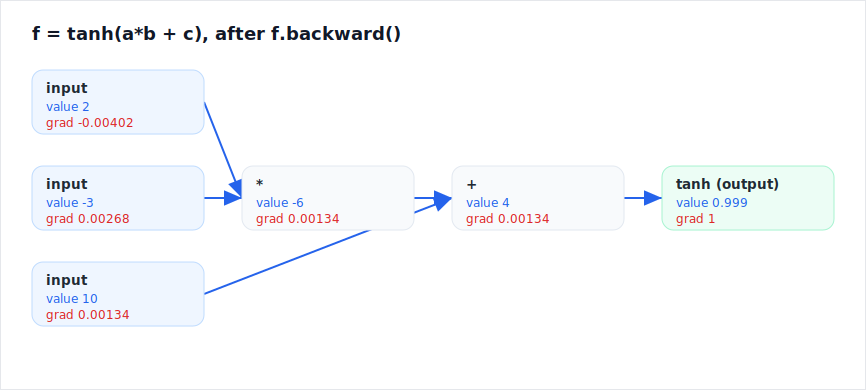

In [11]:
# engine.py is the same construction on NumPy arrays, and viz.py draws the
# graph a Tensor expression actually built, each node showing its value and
# the gradient backward() filled in.

import tempfile
from pathlib import Path

from IPython.display import SVG

from engine import Tensor
from viz import draw_dot

a, b, c = Tensor(2.0), Tensor(-3.0), Tensor(10.0)
f = (a * b + c).tanh()
f.backward()
print(f"f = {float(f.data):.6f}   df/da = {float(a.grad):.6f}   df/db = {float(b.grad):.6f}")

path = Path(tempfile.gettempdir()) / "walkthrough_graph.svg"
draw_dot(f, str(path), title="f = tanh(a*b + c), after f.backward()")
SVG(filename=str(path))

Where this goes next in the repo:

- `GUIDE.md` walks the tensor engine, `engine.py`, where the one new problem is broadcasting: a value broadcast up in the forward pass needs its gradient summed back down to the original shape in the backward pass. The guide has exercises along the way, with the test suite (PyTorch as a reference, finite differences, the forward/reverse adjoint identity) as the oracle to check answers against.
- `challenge/` is the rebuild-it-yourself track: skeleton files with the contracts documented and numbered checkpoint tests, so `uv run python -m pytest challenge -x` always points at the next thing to implement.
- `dual.py` is forward mode: the same chain rule pushed from inputs to outputs, carrying a tangent instead of building a graph.
